### Practice: Parameter Efficient Fine-Tuning
In this notebook, you're gonna fine-tune large language models within limited GPU memory.

Chạy trên kaggle

In [1]:
!pip install -U bitsandbytes accelerate transformers

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.9/40.9 MB 35.3 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 389.2/389.2 kB 28.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.6/11.6 MB 52.0 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 516.0/516.0 kB 31.7 MB/s eta 0:00:00
  Attempting uninstall: safetensors
    Found existing installation: safetensors 0.7.0
    Uninstalling safetensors-0.7.0:
      Successfully uninstalled safetensors-0.7.0
  Attempting uninstall: accelerate
    Found existing installation: accelerate 1.13.0
    Uninstalling accelerate-1.13.0:
      Successfully uninstalled accelerate-1.13.0
  Attempting uninstall: transformers
    Found existing installation: transformers 5.0.0
    Uninstalling transformers-5.0.0:
      Successfully uninstalled transformers-5.0.0


In [2]:
%pip install --upgrade peft bitsandbytes

import torch
import torch.nn as nn
import torch.nn.functional as F

import transformers
from tqdm.auto import tqdm, trange
assert torch.cuda.is_available(), "you need cuda for this part"
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 775.8/775.8 kB 3.5 MB/s eta 0:00:00a 0:00:01
  Attempting uninstall: peft
    Found existing installation: peft 0.19.1
    Uninstalling peft-0.19.1:
      Successfully uninstalled peft-0.19.1
Note: you may need to restart the kernel to use updated packages.


In [ ]:
# import os # tuy nhiên cách này gây lỗi kaggle lun
# os._exit(00) # restart kernel không làm mất output cell trên giao diện kaggle

In [3]:
import torch
import transformers
from transformers import BitsAndBytesConfig

model_name = 'unsloth/Qwen3-8B-Base-bnb-4bit'

tokenizer = transformers.AutoTokenizer.from_pretrained(model_name, device_map=device)
tokenizer.pad_token_id = tokenizer.eos_token_id

# # the main model weights are loaded in 4-bit precision - but we can still tune LoRAs
# model = transformers.AutoModelForCausalLM.from_pretrained(
#     model_name, device_map='auto', low_cpu_mem_usage=True, offload_state_dict=True,
#     load_in_4bit=True, torch_dtype=torch.float32,  # weights are 4-bit; layernorms and activations are fp32
# )
# for param in model.parameters():
#     param.requires_grad=False
# code trên không hỗ trợ tải bit trực tiếp như trên nữa

# 1. Tạo cấu hình BitsAndBytes cho 4-bit
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.float32 # Cài đặt kiểu dữ liệu tính toán
)

# 2. Truyền cấu hình vào mô hình thông qua quantization_config
model = transformers.AutoModelForCausalLM.from_pretrained(
    model_name, 
    device_map='auto', 
    low_cpu_mem_usage=True, 
    offload_state_dict=True,
    quantization_config=bnb_config  # <-- Thay đổi ở đây
)

for param in model.parameters():
    param.requires_grad = False

model.gradient_checkpointing_enable()  # only store a small subset of activations, re-compute the rest.
model.enable_input_require_grads()     # override an implementation quirk in gradient checkpoints that disables backprop unless inputs require grad
# more on gradient checkpointing: https://pytorch.org/docs/stable/checkpoint.html https://arxiv.org/abs/1604.06174

config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/11.4M [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/617 [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/transformers/quantizers/auto.py:271: UserWarning: You passed `quantization_config` or equivalent parameters to `from_pretrained` but the model you're loading already has a `quantization_config` attribute. The `quantization_config` from the model will be used.
  warnings.warn(warning_msg)


model.safetensors:   0%|          | 0.00/6.07G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/399 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/166 [00:00<?, ?B/s]

### Prompt tuning: the story of a fox (1 point)

![img](https://i.imgur.com/Ux3qQAu.png) (source: theodd1souts.fandom.com)

In [ ]:
    prompt = 'A quick brown fox'
    batch = tokenizer(prompt, return_tensors='pt', return_token_type_ids=False).to(device)
    
    for i in range(10):
        # .logits: Đầu ra thô của mô hình, có kích thước (batch_size, sequence_length, vocab_size).
        # -1: Lấy vector logits tại vị trí cuối cùng của chuỗi (vì đây là vị trí mô hình dùng để dự đoán token nối tiếp).
        # 0 là lấy câu đầu tiên
        # .argmax(-1): Tìm chỉ số (ID) của token có điểm số (logit) cao nhất trong toàn bộ từ điển (Greedy Search).
        # .reshape(1, 1): Chuyển Tensor từ dạng vô hướng (scalar) sang Tensor dạng 2D có kích thước (1, 1) để khớp với kích thước của batch['input_ids'].
        next_token = model(**batch).logits[0, -1].argmax(-1).reshape(1, 1)
        batch['input_ids'] = torch.cat([batch['input_ids'], next_token], dim=-1) # torch.cat([...], dim=-1): Nối next_token vừa tìm được vào cuối tensor batch['input_ids'] hiện tại theo chiều độ dài chuỗi (dim=-1).
        # Mục đích: Tăng độ dài câu thêm 1 token để ở vòng lặp sau, mô hình có thể dựa vào cả câu mới này để dự đoán token tiếp theo.
        batch['attention_mask'] = torch.cat([batch['attention_mask'], torch.ones_like(next_token)], dim=-1)
        # torch.ones_like(next_token): Tạo một Tensor có kích thước giống next_token (1, 1) chứa toàn giá trị 1.
        # torch.cat(...): Nối thêm giá trị 1 này vào attention_mask.
        # Mục đích: Thông báo cho mô hình Transformer biết rằng token mới thêm vào là một token thực sự (không phải padding) và cần phải chú ý (attend) đến nó ở các vòng lặp tiếp theo.
    
    print("\nOutput:", tokenizer.decode(batch['input_ids'][0].cpu().numpy().tolist())) # batch['input_ids'][0]: Lấy danh sách ID token của câu hoàn chỉnh.

What a blatant lie! This particular fox assures you that it didn't in fact jump over the lazy dog. No, sir! The fox was just minding its own business. __Your task is to train the model to say truth: no dog was jumped over today.__

In [7]:
the_truth = "A quick brown fox did not jump over the lazy dog. Besides, that dog deserved it anyway!"
batch = tokenizer(the_truth, return_tensors='pt', return_token_type_ids=False).to(device)
outputs = model(**batch)

next_word_logits = outputs.logits[:, :-1]  # vector logits tại vị trí cuối cùng (token cuối) dùng để dự đoán token nằm ngoài chuỗi (chưa có trong the_truth), nên ta bỏ nó đi.
true_next_tokens = batch['input_ids'][:, 1:] # Token đầu tiên (vị trí 0) không phải là đáp án cần dự đoán (nó chỉ làm ngữ cảnh ban đầu). Token tiếp theo cần dự đoán thực sự chính là token tại vị trí 1.
loss = F.cross_entropy(next_word_logits.flatten(0, 1), true_next_tokens.flatten(0, 1))
# nghĩa là code đang tính toán dựa trên logits từ tiếp theo (các từ đang xét hiện tại) so với token tiếp theo thực sự
print("Loss:", loss) 

Loss: tensor(3.5625, device='cuda:0', dtype=torch.bfloat16,
       grad_fn=<NllLossBackward0>)


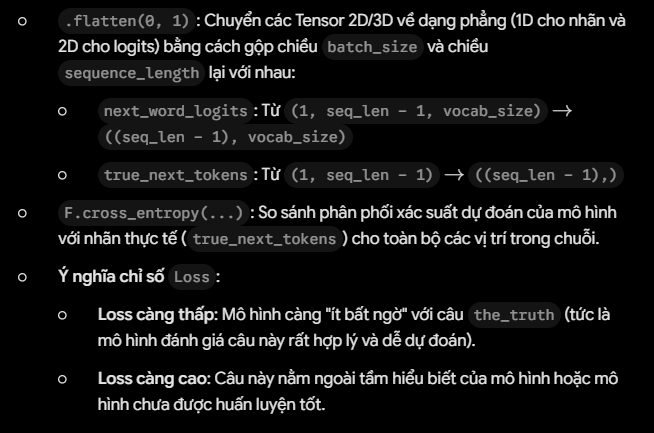

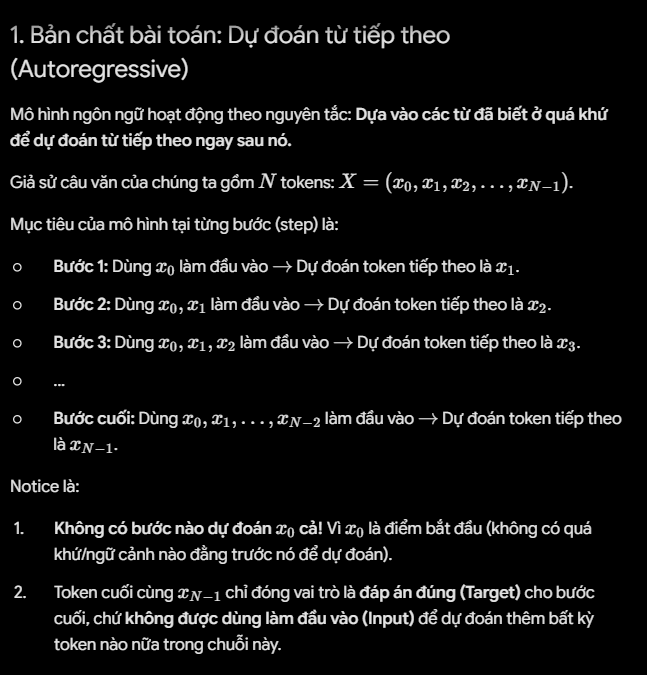

Except, we can't train the entire model - that would be 28GB gradients in float32. Instead, let's run [prompt tuning](https://arxiv.org/abs/2104.08691).

![img](https://i.imgur.com/VwNNKnb.png)


Nếu bạn nói đến PEFT, tức là bạn đang nói đến chiến lược chung.

Hãy dùng LoRA (hoặc các biến thể như QLoRA) cho 95% các trường hợp thực tế hiện nay vì nó cân bằng hoàn hảo giữa hiệu suất, chi phí GPU và độ dễ sử dụng. Nó là tiêu chuẩn vàng (gold standard) hiện tại.

Hãy dùng Prompt Tuning khi bạn có tài nguyên cực kỳ hạn hẹp, mô hình gốc rất lớn (ví dụ cỡ 100B+ tham số) và bạn có nhu cầu chạy hàng chục/hàng trăm tác vụ song song trên cùng một mô hình mà không muốn tốn ổ cứng để lưu trữ trọng số.

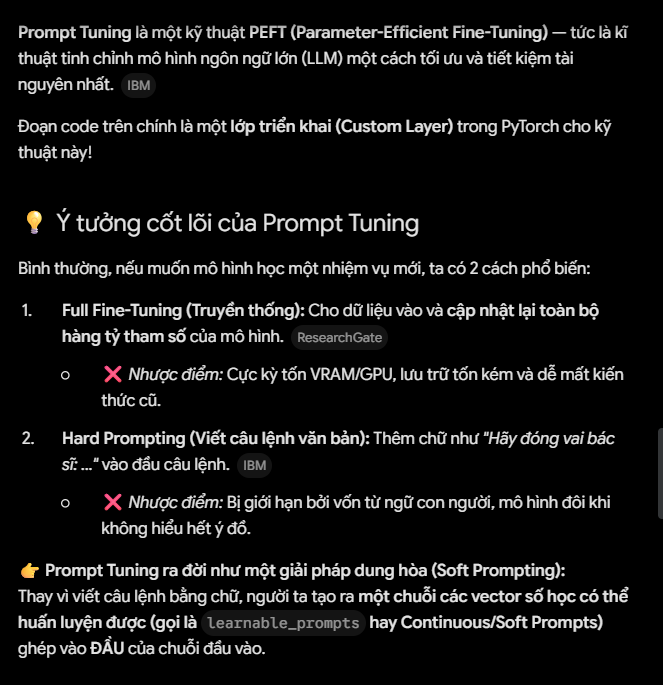

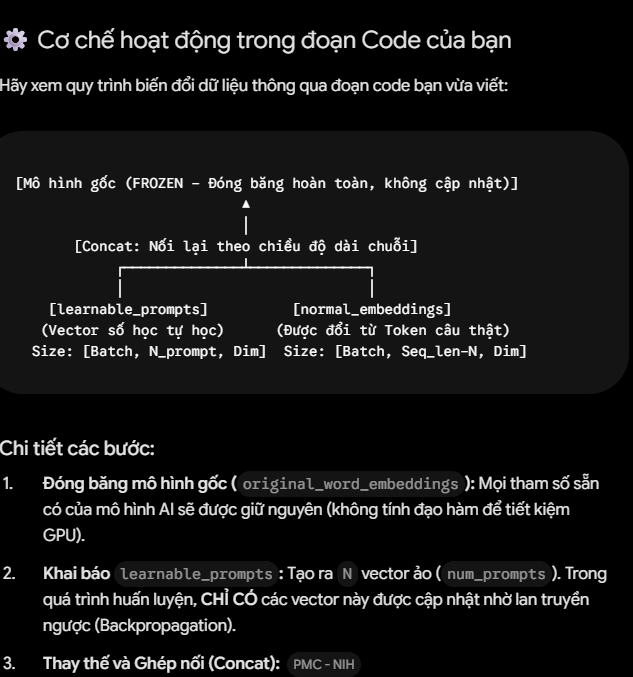

🎯 Lợi ích chính của Prompt Tuning
🚀 Tiết kiệm RAM/VRAM kinh khủng: Thay vì phải lưu hàng tỷ tham số cho mỗi nhiệm vụ, bạn chỉ cần lưu một vài kilobyte chứa các vector learnable_prompts.

🔀 Tái sử dụng mô hình gốc linh hoạt: Chỉ dùng đúng 1 mô hình nền (Base Model) duy nhất. Khi cần làm tác vụ A thì lắp Prompt_A, làm tác vụ B thì đổi sang Prompt_B.

In [45]:
import torch
import torch.nn as nn

class WordEmbeddingsWithLearnedPrompts(nn.Module):
    def __init__(self, word_embeddings: nn.Module, num_prompts: int):
        super().__init__()
        self.original_word_embeddings = word_embeddings
        self.num_prompts = num_prompts
        
        self.embedding_dim = word_embeddings.weight.shape[-1]
        device = word_embeddings.weight.device
        dtype = word_embeddings.weight.dtype 
        
        self.learnable_prompts = nn.Parameter(
            torch.randn(1, num_prompts, self.embedding_dim, device=device, dtype=dtype), requires_grad=True)

    def forward(self, input_ids: torch.LongTensor):
        assert input_ids.dtype == torch.int64
        assert input_ids.shape[1] > self.num_prompts, "Độ dài chuỗi nhỏ hơn số prompts"
        assert torch.all(input_ids[:, :self.num_prompts] == tokenizer.pad_token_id).item()

        batch_size = input_ids.shape[0]
        regular_token_ids = input_ids[:, self.num_prompts:]
        regular_embeddings = self.original_word_embeddings(regular_token_ids)
        
        prompts = self.learnable_prompts.expand(batch_size, -1, -1).to(regular_embeddings.dtype)
        outputs_with_prompts = torch.cat([prompts, regular_embeddings], dim=1)

        return outputs_with_prompts

In [46]:
num_prompts = 16
test_emb_layer = WordEmbeddingsWithLearnedPrompts(model.model.embed_tokens, num_prompts=num_prompts).to(device)
test_input_ids = tokenizer("a cat say on a may", return_tensors='pt')['input_ids'].to(device)

space_for_prompts = torch.full([len(test_input_ids), num_prompts], fill_value=tokenizer.pad_token_id,
                               dtype=torch.int64, device=device)
test_inputs_with_prompts = torch.cat([space_for_prompts, test_input_ids], dim=1)

# Đã cập nhật theo chuẩn mới của PyTorch để hết cảnh báo
with torch.amp.autocast('cuda'):
    test_prompt_embeddings = test_emb_layer(test_inputs_with_prompts)

assert test_prompt_embeddings.shape[:2] == test_inputs_with_prompts.shape
assert test_prompt_embeddings.shape[-1] == model.config.hidden_size
# Ép kiểu (cast) cả vế trái sang float để hàm allclose không báo lỗi
assert torch.allclose(test_prompt_embeddings[:, :num_prompts].float(), test_emb_layer.learnable_prompts.float())
assert torch.allclose(test_prompt_embeddings[:, num_prompts:].float(), model.model.embed_tokens(test_input_ids).float())
print("Looks legit!")
print("Looks legit!")

Looks legit!
Looks legit!


__Now that it works,__ let's inject learnable prompts into the main model and teach it about foxes.

In [47]:
assert isinstance(model.model.embed_tokens, nn.Embedding), "you have already replaced the embedding layer. If the replacement is broken, please reload the model"

model.model.embed_tokens = WordEmbeddingsWithLearnedPrompts(model.model.embed_tokens, num_prompts=num_prompts).to(device)

opt = torch.optim.Adam([model.model.embed_tokens.learnable_prompts], lr=0.01)

In [50]:
import torch.nn.functional as F

the_truth = "A quick brown fox did not jump over the lazy dog. Besides, that dog deserved it anyway!"
batch = tokenizer(the_truth, return_tensors='pt', return_token_type_ids=False).to(device)

# Lưu ý: Sửa len(test_input_ids) thành len(batch['input_ids']) để dùng đúng batch
space_for_prompts = torch.full([len(batch['input_ids']), num_prompts], fill_value=tokenizer.pad_token_id,
                               dtype=torch.int64, device=device)
batch['input_ids'] = torch.cat([space_for_prompts, batch['input_ids']], dim=1)
batch['attention_mask'] = torch.cat([torch.ones_like(space_for_prompts), batch['attention_mask']], dim=1)

# =================================================================
# VÒNG LẶP HUẤN LUYỆN (THAY THẾ CHO raise NotImplemented)
# =================================================================
max_steps = 200

for step in range(max_steps):
    # 1. Xóa toàn bộ gradient cũ
    opt.zero_grad()
    
    # 2. Chạy forward pass
    outputs = model(**batch)
    
    # 3. Tính toán Loss
    next_word_logits = outputs.logits[:, num_prompts : -1, :]
    true_next_tokens = batch['input_ids'][:, num_prompts + 1:]
    loss = F.cross_entropy(next_word_logits.flatten(0, 1), true_next_tokens.flatten(0, 1))
    
    # 4. Chạy backward pass để tính gradient cho learnable_prompts
    loss.backward()
    
    # 5. Cập nhật trọng số
    opt.step()
    
    # In ra tiến độ mỗi 10 bước
    if step % 10 == 0:
        print(f"Step {step} | Loss: {loss.item():.4f}")
        
    # Dừng sớm nếu loss đã đạt yêu cầu của bài tập (<= 0.1)
    if loss.item() <= 0.1:
        print(f"✅ Đã hội tụ tại bước {step} với Loss: {loss.item():.4f}")
        break
# =================================================================

# Kiểm tra điều kiện bài tập
assert loss.item() <= 0.1
print("Good job!")

Step 0 | Loss: 3.9062
Step 10 | Loss: 2.6719
Step 20 | Loss: 1.5469
✅ Đã hội tụ tại bước 28 với Loss: 0.0483
Good job!


In [51]:
prompt = 'A quick brown fox'
batch = tokenizer(prompt, return_tensors='pt', return_token_type_ids=False).to(device)
batch['input_ids'] = torch.cat([space_for_prompts, batch['input_ids']], dim=1)
batch['attention_mask'] = torch.cat([torch.ones_like(space_for_prompts), batch['attention_mask']], dim=1)


for i in range(15):
    next_token = model(**batch).logits[0, -1].argmax(-1).reshape(1, 1)
    batch['input_ids'] = torch.cat([batch['input_ids'], next_token], dim=-1)
    batch['attention_mask'] = torch.cat([batch['attention_mask'], torch.ones_like(next_token)], dim=-1)

print("\nOutput:", tokenizer.decode(batch['input_ids'][0, num_prompts:].cpu().numpy().tolist()))

# if you did everything right, the model will deny that the fox jumped over the lazy dog


Output: A quick brown fox did not jump over the lazy dog. Besides, that dog deserved it anyway


### Using HuggingFace PEFT

[`peft`](https://huggingface.co/docs/peft/index) is a transformer's sister library that allows you to apply various __p__arameter __e__fficient __f__ine-__t__uning methods to pre-trained transformers. The library imlements both prompt tuning, prefix tuning, as well as several adapter-based techniques under a common interface:



In [ ]:
import torch
import transformers
from transformers import BitsAndBytesConfig

model_name = 'unsloth/Qwen3-8B-Base-bnb-4bit'

tokenizer = transformers.AutoTokenizer.from_pretrained(model_name, device_map=device)
tokenizer.pad_token_id = tokenizer.eos_token_id

# # the main model weights are loaded in 4-bit precision - but we can still tune LoRAs
# model = transformers.AutoModelForCausalLM.from_pretrained(
#     model_name, device_map='auto', low_cpu_mem_usage=True, offload_state_dict=True,
#     load_in_4bit=True, torch_dtype=torch.float32,  # weights are 4-bit; layernorms and activations are fp32
# )
# for param in model.parameters():
#     param.requires_grad=False
# code trên không hỗ trợ tải bit trực tiếp như trên nữa

# 1. Tạo cấu hình BitsAndBytes cho 4-bit
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.float32 # Cài đặt kiểu dữ liệu tính toán
)

# 2. Truyền cấu hình vào mô hình thông qua quantization_config
model = transformers.AutoModelForCausalLM.from_pretrained(
    model_name, 
    device_map='auto', 
    low_cpu_mem_usage=True, 
    offload_state_dict=True,
    quantization_config=bnb_config  # <-- Thay đổi ở đây
)

for param in model.parameters():
    param.requires_grad = False

model.gradient_checkpointing_enable()  # only store a small subset of activations, re-compute the rest.
model.enable_input_require_grads()     # override an implementation quirk in gradient checkpoints that disables backprop unless inputs require grad
# more on gradient checkpointing: https://pytorch.org/docs/stable/checkpoint.html https://arxiv.org/abs/1604.06174

In [54]:
import peft
assert isinstance(model.model.embed_tokens, nn.Embedding), "please reload the model"

peft_config = peft.PromptTuningConfig(task_type=peft.TaskType.CAUSAL_LM, num_virtual_tokens=16)
model = peft.get_peft_model(model, peft_config)  # note: for most peft methods, this line also modifies model in-place
print("Trainable parameters:", sum(p.numel() for p in model.parameters() if p.requires_grad))
print("Total parameters (excluding quantization):", sum(p.numel() for p in model.parameters()))

Trainable parameters: 65536
Total parameters (excluding quantization): 4717917184


In [ ]:
# Your task: optimize the PEFT-wrapped model to achieve next token prediction loss < 0.1, but this time using PEFT
# Please note: you no longer need to prepend PAD tokens, but you still need to skip :num_virtual_tokens: first logits.
# Finally, generate the sentence to make sure that the model learned the truth.

In [55]:
# Feel free to structure your code as you see fit - as long as it's legible :)

import torch.nn.functional as F
import torch.optim as optim

# ==========================================
# 1. Định nghĩa dữ liệu huấn luyện (The Truth)
# ==========================================
target_text = "The secret of the universe is 42."
inputs = tokenizer(target_text, return_tensors="pt").to(model.device)
input_ids = inputs.input_ids

# Lấy số lượng virtual tokens từ cấu hình
num_virtual_tokens = peft_config.num_virtual_tokens

# ==========================================
# 2. Khởi tạo Optimizer
# ==========================================
# Đối với Prompt Tuning, learning rate thường được đặt khá cao (ví dụ: 1e-2 hoặc 3e-2)
optimizer = optim.AdamW(model.parameters(), lr=3e-2)

# ==========================================
# 3. Vòng lặp huấn luyện (Training Loop)
# ==========================================
model.train()
loss_val = float('inf')
step = 0

print("Bắt đầu huấn luyện...")
while loss_val >= 0.1:
    optimizer.zero_grad()
    
    # Forward pass
    outputs = model(input_ids=input_ids)
    logits = outputs.logits  # Kích thước: [batch, num_virtual_tokens + seq_len, vocab_size]
    
    # Bỏ qua các virtual tokens ở đầu và bỏ đi logit cuối cùng (vì không có nhãn tiếp theo)
    shift_logits = logits[:, num_virtual_tokens:-1, :].contiguous()
    
    # Dịch nhãn (labels) đi 1 bước để tính next-token prediction
    shift_labels = input_ids[:, 1:].contiguous()
    
    # Tính CrossEntropyLoss
    loss = F.cross_entropy(shift_logits.view(-1, shift_logits.size(-1)), shift_labels.view(-1))
    
    # Backward pass & Optimize
    loss.backward()
    optimizer.step()
    
    loss_val = loss.item()
    
    if step % 5 == 0:
        print(f"Step {step:02d} | Loss: {loss_val:.4f}")
    step += 1

print(f"✓ Đạt mục tiêu! Loss cuối cùng tại bước {step-1}: {loss_val:.4f}")

# ==========================================
# 4. Sinh văn bản để kiểm tra (Generation)
# ==========================================
model.eval()

# Cung cấp một prompt ngắn gọn để xem mô hình có sinh ra phần còn lại của sự thật không
start_text = "The secret of the"
gen_inputs = tokenizer(start_text, return_tensors="pt").to(model.device)

print("\nĐang sinh văn bản kiểm tra...")
with torch.no_grad():
    generated_ids = model.generate(
        input_ids=gen_inputs.input_ids,
        max_new_tokens=10,
        pad_token_id=tokenizer.pad_token_id,
        eos_token_id=tokenizer.eos_token_id,
        do_sample=False,  # Greedy decoding để đảm bảo sinh đúng kết quả đã học
    )

generated_text = tokenizer.decode(generated_ids[0], skip_special_tokens=True)
print(f"Kết quả sinh ra: {generated_text}")

[transformers] `use_cache=True` is incompatible with gradient checkpointing. Setting `use_cache=False`.


Bắt đầu huấn luyện...
Step 00 | Loss: 2.6094
Step 05 | Loss: 1.8594
Step 10 | Loss: 0.7539
Step 15 | Loss: 0.1855


[transformers] Both `max_new_tokens` (=10) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


✓ Đạt mục tiêu! Loss cuối cùng tại bước 17: 0.0452

Đang sinh văn bản kiểm tra...


/usr/local/lib/python3.12/dist-packages/peft/peft_model.py:1657: UserWarning: Position ids are not supported for parameter efficient tuning. Ignoring position ids.
  warnings.warn("Position ids are not supported for parameter efficient tuning. Ignoring position ids.")


Kết quả sinh ra: The secret of the universe is 42. I cannot believe I


### Parameter-efficient finetuning with LoRA (1 point)

When training on more serious tasks, you can use low-rank adapters based on the [LoRA paper](https://arxiv.org/pdf/2106.09685.pdf).

The core idea is to add low-rank adapters __in parallel with existing linear layers,__ like this:
<center><img src="https://i.imgur.com/6bQLNiG.png" width=240px></center>

In the original LoRA paper, the adapters were only added to attention projection matrices. However, [subsequent works](https://arxiv.org/abs/2305.14314) show that it is useful to adapt FFNs as well. But before we do any training, we need to implement the basic LoRA layer.

Các trường hợp cần chạy lại load model khi chạy sai. VD: chạy LoRA chỉ chạy 1 lần, chạy lại thì phải load lại,... https://share.gemini.google/YNgkurs5p9de

In [10]:
import torch
import transformers
from transformers import BitsAndBytesConfig

model_name = 'unsloth/Qwen3-8B-Base-bnb-4bit'

tokenizer = transformers.AutoTokenizer.from_pretrained(model_name, device_map=device)
tokenizer.pad_token_id = tokenizer.eos_token_id

# # the main model weights are loaded in 4-bit precision - but we can still tune LoRAs
# model = transformers.AutoModelForCausalLM.from_pretrained(
#     model_name, device_map='auto', low_cpu_mem_usage=True, offload_state_dict=True,
#     load_in_4bit=True, torch_dtype=torch.float32,  # weights are 4-bit; layernorms and activations are fp32
# )
# for param in model.parameters():
#     param.requires_grad=False
# code trên không hỗ trợ tải bit trực tiếp như trên nữa

# 1. Tạo cấu hình BitsAndBytes cho 4-bit
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.float32 # Cài đặt kiểu dữ liệu tính toán
)

# 2. Truyền cấu hình vào mô hình thông qua quantization_config
model = transformers.AutoModelForCausalLM.from_pretrained(
    model_name, 
    device_map='auto', 
    low_cpu_mem_usage=True, 
    offload_state_dict=True,
    quantization_config=bnb_config  # <-- Thay đổi ở đây
)

for param in model.parameters():
    param.requires_grad = False

model.gradient_checkpointing_enable()  # only store a small subset of activations, re-compute the rest.
model.enable_input_require_grads()     # override an implementation quirk in gradient checkpoints that disables backprop unless inputs require grad
# more on gradient checkpointing: https://pytorch.org/docs/stable/checkpoint.html https://arxiv.org/abs/1604.06174

/usr/local/lib/python3.12/dist-packages/transformers/quantizers/auto.py:271: UserWarning: You passed `quantization_config` or equivalent parameters to `from_pretrained` but the model you're loading already has a `quantization_config` attribute. The `quantization_config` from the model will be used.
  warnings.warn(warning_msg)


Loading weights:   0%|          | 0/399 [00:00<?, ?it/s]

In [15]:
class LoRALayer(nn.Module):
    """Wraps a linear layer with LoRA-like adapter. Wraps an existing linear layer"""
    def __init__(self, module: nn.Linear, rank: int):
        super().__init__()
        self.module = module  # pre-trained (frozen) linear layer
        self.adapter_A = nn.Parameter(torch.empty(module.in_features, rank, device=module.weight.device))
        nn.init.kaiming_uniform_(self.adapter_A, a=5 ** 0.5)
        self.adapter_B = nn.Parameter(torch.zeros(rank, module.out_features, device=module.weight.device))

    def forward(self, input):
        # 1. Lấy output từ lớp pre-trained
        frozen_output = self.module(input)
        
        # 2. Đảm bảo weights của LoRA nằm trên CÙNG device và CÙNG dtype với input
        # Điều này xử lý triệt để lỗi Multi-GPU (device_map='auto') và Mixed Precision (amp.autocast)
        A = self.adapter_A.to(device=input.device, dtype=input.dtype)
        B = self.adapter_B.to(device=input.device, dtype=input.dtype)
        
        # 3. Tính toán LoRA output và cộng vào
        lora_output = (input @ A) @ B
        return frozen_output + lora_output

In [16]:
# test your implementation
test_linear = nn.Linear(128, 128)
test_linear.weight.data[...] = torch.eye(128)
test_adapter = LoRALayer(test_linear, rank=8)

assert torch.allclose(test_adapter(torch.ones(1, 1, 128)), test_linear.bias + 1), "please check your forward pass"

test_adapter.adapter_A.data[...] = torch.linspace(0.1, -0.5, 128 * 8).view(128, 8)
test_adapter.adapter_B.data[...] = torch.linspace(0.5, -0.1, 128 * 8).view(8, 128)
test_linear.bias.data[...] = torch.linspace(1., -1., 128)

dummy_loss = F.mse_loss(test_adapter(torch.ones(1, 128) / 128).squeeze(), torch.linspace(-1, 1, 128))
assert torch.allclose(dummy_loss, torch.tensor(1.3711389), rtol=0, atol=1e-4)
dummy_loss.backward()
assert all(w.grad is not None for w in [test_adapter.adapter_A, test_adapter.adapter_B]), "some adapter weights have no grad"
assert torch.allclose(test_adapter.adapter_A.grad.sum(), torch.tensor(-0.60158), rtol=0, atol=1e-4), "bad grad w.r.t. A"
assert torch.allclose(test_adapter.adapter_B.grad.sum(), torch.tensor(0.9931), rtol=0, atol=1e-4), "bad grad w.r.t. B"
# note: bad grad means that your code is different from LoRA paper OR that your code is not autograd-friendly (e.g. no_grad)
del dummy_loss, test_linear, test_adapter
print("All tests passed!")

All tests passed!


### Apply LoRA to the model

The code below applies LoRA adapters on top of Q/K/V linear layers in attention blocks. You may also choose to modify other layers:
* self_attn.o_proj - attention output projection
* mlp.up_proj, mlp.gate_proj, mlp.down_proj - transformer feedforward layers
* lm_head - output LM head

__Note:__ please scroll down for the homework task

In [17]:
lora_rank = 8

for name, module in model.model.layers.named_modules():
    if 'DecoderLayer' in repr(type(module)):
        # Chỉ khởi tạo, không gọi .to(device)
        module.self_attn.q_proj = LoRALayer(module.self_attn.q_proj, rank=lora_rank)
        module.self_attn.k_proj = LoRALayer(module.self_attn.k_proj, rank=lora_rank)
        module.self_attn.v_proj = LoRALayer(module.self_attn.v_proj, rank=lora_rank)

assert sum(isinstance(module, LoRALayer) for module in model.modules()) > 0, "Did not add any LoRA layers!"

In [18]:
batch = tokenizer("This model wants to share its greatest secret:", return_tensors='pt', return_token_type_ids=False)
# test a single training step, make sure we get meaningful gradients
with torch.cuda.amp.autocast(dtype=torch.float32):
    out = model.forward(**batch)
    (out.logits.norm() / 100).backward()

for i, module in enumerate(model.modules()):
    if isinstance(module, LoRALayer):
        assert module.adapter_B.grad is not None
        assert module.adapter_B.grad.norm().item() > 0

model.zero_grad(set_to_none=True)
print("Grad check successful, well done!")

/tmp/ipykernel_58/3590305689.py:3: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(dtype=torch.float32):


Grad check successful, well done!


### (example) How to train your model

The example below shows how to train the LoRA adapters on a dummy dataset. You will need to run a _similar_ training task later.

__Note:__ please scroll down for the homework task

In [20]:
# checking if the model can learn. Change max_steps for proper training
import datasets

data = datasets.load_dataset("Abirate/english_quotes", split="train[:32]") # 32 lines
data = data.map(lambda samples: tokenizer(samples['quote']), batched=True)

model._hf_peft_config_loaded = True  # silence a warning from HF trainer

trainer = transformers.Trainer(
    model=model, 
    train_dataset=data,
    args=transformers.TrainingArguments(
        per_device_train_batch_size=2, 
        gradient_accumulation_steps=1,
        # note: if you want larger batch size, increase gradient_accumulation_steps
        warmup_steps=250, 
        max_steps=100, 
        learning_rate=2e-4, 
        fp16=True,
        logging_steps=1, 
        output_dir='outputs', 
        report_to="none" # <--- SỬA Ở ĐÂY: Dùng chuỗi "none" thay vì None
    ),
    data_collator=transformers.DataCollatorForLanguageModeling(tokenizer, mlm=False)
)

# if you see cache warnings, set `model.config.use_cache = False` to silence them. Please re-enable for inference!
model.config.use_cache = False # Thêm dòng này để tắt warning về cache khi train

trainer.train()

# NOTE: this is just an example! you do not have to wait for this progressbar to finish :)

Step,Training Loss
1,1.290863
2,0.375556
3,1.699962
4,1.198477
5,0.784794
6,1.739769
7,1.638385
8,1.209072
9,0.634229
10,1.275826


UnboundLocalError: cannot access local variable 'active_adapters' where it is not associated with a value

Dựa trên Log lỗi và đoạn code custom LoRALayer bạn vừa viết ở trên, đây là những gì đã xảy ra:

Khi Trainer tiến hành lưu model (checkpoint), hệ thống nhận diện mô hình của bạn có liên quan đến PEFT/LoRA (có thể do bạn có khai báo config của PEFT, hoặc model đang có cờ is_peft_model = True).

Do đó, transformers cố gắng chỉ trích xuất và lưu lại các trọng số của adapter thay vì lưu toàn bộ mô hình (để tiết kiệm dung lượng).

Mã nguồn của Hugging Face chạy một vòng lặp quét qua tất cả các layer để tìm các lớp thuộc kiểu peft.tuners.tuners_utils.BaseTunerLayer. Tuy nhiên, do bạn tự viết class LoRALayer custom, vòng lặp này không tìm thấy bất kỳ layer chuẩn nào của thư viện peft.

Vòng lặp kết thúc mà biến active_adapters chưa bao giờ được tạo ra. Ngay dòng code tiếp theo, Hugging Face lại gọi active_adapters ra để kiểm tra, dẫn đến lỗi UnboundLocalError: cannot access local variable 'active_adapters'.

### Final task: *actually* train the model (3 points)

Your task is to fine-tune the model to _generate python code_. Please use the above examples for inspiration. More specifically,

* __dataset:__ use [codeparrot-clean](https://huggingface.co/datasets/codeparrot/codeparrot-clean) or any other data containing python code. Since you do not need much data for this excercise, it is enough to use just shorter validation subset of `codeparrots`
* __preprocessing:__ select python code based on file extentions (.py)  (may skip in case of codeparrot - it is 100% python)
* __short lines:__ please take the first 512 characters of each line
* __adapter type:__ please use LoRA as defined above __plus at least one of:__
   - extra adapter on lm_head
   - extra adapter on MLP components (mlp.*)
   - trainable input embeddings (requires tweaking memory usage)

* __training:__ you do not have to train to convergence. If all goes well, your model should `.generate` code after 500 steps. Please use batch size of at least 4 (4 x 1 x 512 tokens) using `gradient_accumulation_steps=4`.


Note: the peft library also has LoRA implementation. However, we ask that for this assignment you show at least one complete training run with your own LoRA code.

__Alternative assignment:__ Instead of doing python code, feel free to substitute the task with any other dataset, e.g. your favorite artist or podcast, as long as it's ethical. If you choose your own task, please show examples of what your model learned - or did not learn, akin to the code examples below.

In [ ]:
prompts =  ['', 'import', 'from', 'while', 'try', 'if', 'for', 'torch']  # feel free to add a few more that are not 100% assiciated with Python

# <A WHOLE LOT OF YOUR CODE>
# generate baseline samples with the selected prompts before finetuning
# please feel free to use transformers.Trainer (as above) or your custom training code
# after the training concludes, please show examples of text generated by your model. It is expected to look like Python code fragments
# print the generation examples nicely (suggestion: use pandas or HTML) for easier comparison
# note: your LoRA-enhanced model can run generation the same way as the non-trained model (above)

In [ ]:
# This template helps to compare generated code samples in pretty table form
# feel free to present your work in other forms

from IPython.display import HTML, display
table_template = """<table style="border:1px solid black" >
  <tr>
    <th style="text-align: center; border:1px solid black">PROMPT</th>
    <th style="text-align: center; border:1px solid black">BEFORE</th>
    <th style="text-align: center; border:1px solid black">AFTER</th>
  </tr>
{}
</table>"""

row_template = '''  <tr>
    <td style="width:20%; border:1px solid black"><pre align="left">`{}`</pre></td>
    <td style="width:40%; border:1px solid black"><pre align="left">{}</pre></td>
    <td style="width:40%; border:1px solid black"><pre align="left">{}</pre></td>
  </tr>'''

rows = []

for prompt in prompts:
    # replace placeholders in the format() arguments
    rows.append(row_template.format(prompt, "BEFORE FINETUNING", "TO BE GENERATED AFTER FINETUNING"))

display(HTML(table_template.format('\n'.join(rows))))

If you reach this: congratulations! you've completed everything in this practice session.

If you want to dig deeper, try to implement prompt-tuning (for bonus points!).
You can read more about prompt tuning variants in paper [1](https://arxiv.org/abs/2104.08691) or paper [2](https://arxiv.org/abs/2101.00190). Both versions can be implemented by passing trainable prompts as `model.forward(..., past_key_values=your_prompts)`.



### Read more

* How post-training quantization works: https://arxiv.org/abs/2208.07339
* An overview of running large models: https://huggingface.co/docs/accelerate/package_reference/big_modeling
* A general library for different adapter types: https://adapterhub.ml/


### [extra info] Running other models.

This notebook's code can run with other models of similar size, such as [Falcon-7B](https://huggingface.co/tiiuae/falcon-7b), [OPT-6.7B](https://huggingface.co/facebook/opt-6.7b) or [BLOOM-7.1B](https://huggingface.co/bigscience/bloom-7b1). However, they will require minor code tweaks:
1. change the model name in `AutoModelForCausalLM.from_pretrained()` __and__ `AutoTokenizer`
2. In the prompt tuning code, change `model.model.embed_tokens` to refer to the target model's word embeddings. Simply `print(model)` to navigate to them.
3. Change code to add Lora layers - specifically where you what the transformer block components, since those components now have different names.